In [127]:
import os
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

class Chatstate(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

llm = ChatOpenAI(
    openai_api_key=os.getenv("API_KEY"),
    openai_api_base=os.getenv("API_BASE"),
    model_name=os.getenv("MODEL")
)

In [128]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
@tool
def get_battery_status():
    """Returns the current Audi battery percentage and range."""
    return {"battery": "78%", "range": "320km"}

@tool
def open_sunroof():
    """Commands the vehicle to open the sunroof."""
    return {"message": "Sunroof opened"}

@tool
def set_temperature(temp: int):
    """Sets the cabin temperature to a specific degree Celsius."""
    return {"message": f"Cabin temperature set to {temp}°C"}

@tool
def get_vehicle_health():
    """Provides a report of tire pressure, brakes, and oil levels."""
    return {"tire_pressure": "Normal", "oil_level": "Optimal"}

tools = [get_battery_status, open_sunroof, set_temperature, get_vehicle_health]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

In [129]:
def assistant_node(state: Chatstate):
    sys_msg = SystemMessage(content="""
    You are a premium Audi in-car assistant. 
    You have access to: battery, temperature, sunroof, and vehicle health.
    
    If a user asks to open the sunroof, trigger the tool immediately. 
    The system will handle the safety confirmation
    """)
    
    response = llm_with_tools.invoke([sys_msg] + state["messages"])
    return {"messages": [response]}

def should_continue(state: Chatstate):
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [130]:
workflow = StateGraph(Chatstate)

workflow.add_node("assistant", assistant_node)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "assistant")

workflow.add_conditional_edges(
    "assistant",
    should_continue,
    {
        "tools": "tools", 
        END: END           
    }
)

workflow.add_edge("tools", "assistant")

checkpointer = MemorySaver()
chatbot = workflow.compile(checkpointer=checkpointer, interrupt_before=["tools"] )


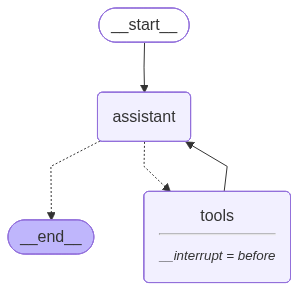

In [131]:
chatbot

In [132]:
config = {"configurable": {"thread_id": "audi_real_hitl"}}

while True:
    user_input = input("\nDriver: ")
    if user_input.lower() in ["quit", "exit"]: break

    print(f"Driver: {user_input}")


    # 1. Start/Continue the graph
    for msg, metadata in chatbot.stream(
        {"messages": [HumanMessage(content=user_input)]}, 
        config, 
        stream_mode="messages"
    ):
        if metadata["langgraph_node"] == "assistant" and msg.content:
            print(msg.content, end="", flush=True)

    # 2. Check if we hit the "interrupt" (waiting for tool approval)
    snapshot = chatbot.get_state(config)
    if snapshot.next:
    # 1. Look at what the AI wants to do
        last_msg = snapshot.values["messages"][-1]
        tool_call = last_msg.tool_calls[0]
    
    # 2. Ask the driver for physical confirmation
        confirm = input(f"\n[VEHICLE SYSTEM]: Proceed with {tool_call['name']}? (yes/no): ")
    
    if confirm.lower() == "yes":
        # Run the tool
        for msg, metadata in chatbot.stream(None, config, stream_mode="messages"):
            if metadata["langgraph_node"] == "assistant" and msg.content:
                print(msg.content, end="", flush=True)
    else:
        # If user says NO, we tell the AI the user cancelled it
        print("\nAssistant: Cancelled.")
        chatbot.update_state(config, {"messages": [HumanMessage(content="I've changed my mind, don't do that.")]})
    print() 

Driver: hello
Hello! How can I assist you with your Audi today?
Driver: open the sunroof
The sunroof has been opened for you. Is there anything else you would like to do?
Driver: no
Alright! If you need any assistance later, feel free to ask. Have a great day!


In [116]:
config = {"configurable": {"thread_id": "audi_real_hitl"}}

while True:
    user_input = input("\nDriver: ")
    if user_input.lower() in ["quit", "exit"]: break

    print(f"Driver: {user_input}")
    print("Assistant: ", end="")

    for msg, metadata in chatbot.stream(
        {"messages": [HumanMessage(content=user_input)]}, 
        config, 
        stream_mode="messages"
    ):
        if metadata["langgraph_node"] == "assistant" and msg.content:
            print(msg.content, end="", flush=True)

    snapshot = chatbot.get_state(config)
    
    if snapshot.next:
        for msg, metadata in chatbot.stream(None, config, stream_mode="messages"):
            if metadata["langgraph_node"] == "assistant" and msg.content:
                print(msg.content, end="", flush=True)

    print() 

Driver: hello
Assistant: Hello! How can I assist you with your Audi's battery, temperature, sunroof, or vehicle health today?
Driver: open suroof
Assistant: May I have your permission to open the sunroof?
Driver: yes
Assistant: The sunroof has been opened. Is there anything else I can assist you with?


In [113]:
list(chatbot.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='f2a423b0-4a40-4701-a758-ce54827cc659'), AIMessage(content='Hello! How can I assist you with your Audi today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 294, 'total_tokens': 308, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_b6f445fc1c', 'id': 'chatcmpl-DZzeAkRRgHCcaSjTz59uSosCwATei', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd984-5805-78d0-8ecb-a73ec6d2a9ec-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 294, 'output_tokens': 14, 'total_tokens': 308, 'input_token_details': {'audio':

In [114]:
config = {"configurable": {"thread_id": "audi_test_session5"}}

print("--- Audi Assistant Online ---")
print("(Type 'quit' to exit)") 

while True:
    user_input = input("\nDriver: ")
    
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Assistant: Shutting down. Safe driving!")
        break

    print(f"Driver: {user_input}")

    output = chatbot.invoke(
        {"messages": [HumanMessage(content=user_input)]}, 
        config=config
    )

    print(f"Assistant: {output['messages'][-1].content}")

--- Audi Assistant Online ---
(Type 'quit' to exit)
Assistant: Shutting down. Safe driving!


In [115]:
list(chatbot.get_state_history(config))

[]